# Training Loop & Single-Task Baselines (Exp-1, Exp-2)

Implements Section 6.1 (Training Configuration) and the first two rows of the Section 6.2 ablation table from `MultiTask_MLP_ChurnLTV_ProjectPlan_v2.pdf`: a generic training loop (Adam, `ReduceLROnPlateau`, early stopping, gradient clipping) applied to the `MultiTaskFMNet` from `03_Model_Architecture.ipynb`, run twice as single-task baselines:

- **Exp-1** (`lambda_churn=1.0, lambda_ltv=0.0`): churn-only — establishes the best-possible churn AUC ceiling.
- **Exp-2** (`lambda_churn=0.0, lambda_ltv=1.0`): LTV-only — establishes the best-possible LTV RMSE ceiling.

Both runs share the same architecture and loss-weighting mechanism (Section 4.4's `Total_Loss = lambda_1 * BCE + lambda_2 * MSE`), so later multi-task experiments (Exp-3 to Exp-7: fixed weights, uncertainty weighting, PCGrad) are directly comparable against these ceilings — that comparison is Section 7.4 / a later notebook, not this one.

In [1]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import average_precision_score, r2_score, roc_auc_score, roc_curve
from torch.utils.data import DataLoader, Dataset

PROCESSED_DIR = os.path.join(os.getcwd(), "data", "processed")
MODELS_DIR = os.path.join(os.getcwd(), "models")
RESULTS_DIR = os.path.join(os.getcwd(), "results")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

with open(os.path.join(PROCESSED_DIR, "feature_manifest.json")) as f:
    manifest = json.load(f)

CAT_COLS = [v["column"] for v in manifest["categorical"].values()]
NUM_COLS = manifest["numerical_scaled"] + manifest["numerical_unscaled"]
CARDINALITIES = {v["column"]: v["cardinality"] for v in manifest["categorical"].values()}
EMBED_DIMS = {v["column"]: v["embedding_dim"] for v in manifest["categorical"].values()}

## Dataset, FM layer, and model (as built in `03_Model_Architecture.ipynb`)

Redefined here so this notebook is self-contained and can be re-run independently.

In [2]:
class KKBoxDataset(Dataset):
    def __init__(self, df):
        self.x_cat = torch.tensor(df[CAT_COLS].values, dtype=torch.long)
        self.x_num = torch.tensor(df[NUM_COLS].values, dtype=torch.float32)
        self.y_churn = torch.tensor(df["is_churn"].values, dtype=torch.float32)
        self.y_ltv = torch.tensor(df["log1p_ltv"].values, dtype=torch.float32)

    def __len__(self):
        return len(self.y_churn)

    def __getitem__(self, idx):
        return self.x_num[idx], self.x_cat[idx], self.y_churn[idx], self.y_ltv[idx]


class FMInteractionLayer(nn.Module):
    def __init__(self, input_dim, k=8):
        super().__init__()
        self.V = nn.Parameter(torch.randn(input_dim, k) * 0.01)

    def forward(self, x):
        xV = x.unsqueeze(2) * self.V.unsqueeze(0)
        sum_then_sq = xV.sum(dim=1).pow(2)
        sq_then_sum = xV.pow(2).sum(dim=1)
        return 0.5 * (sum_then_sq - sq_then_sum)


class MultiTaskFMNet(nn.Module):
    def __init__(self, cat_cols, cardinalities, embed_dims, num_numerical, fm_k=8, backbone_dims=(256, 128, 64)):
        super().__init__()
        self.cat_cols = cat_cols
        self.embeddings = nn.ModuleDict(
            {col: nn.Embedding(cardinalities[col], embed_dims[col]) for col in cat_cols}
        )
        combined_dim = sum(embed_dims[c] for c in cat_cols) + num_numerical
        self.fm = FMInteractionLayer(combined_dim, k=fm_k)

        backbone_input = combined_dim + fm_k
        layers = []
        prev = backbone_input
        dropouts = [0.3, 0.3, 0.2]
        for dim, p in zip(backbone_dims, dropouts):
            layers += [nn.Linear(prev, dim), nn.BatchNorm1d(dim), nn.ReLU(), nn.Dropout(p)]
            prev = dim
        self.backbone = nn.Sequential(*layers)

        self.churn_head = nn.Sequential(nn.Linear(prev, 32), nn.ReLU(), nn.Linear(32, 1))
        self.ltv_head = nn.Sequential(nn.Linear(prev, 32), nn.ReLU(), nn.Linear(32, 1))

    def forward(self, x_num, x_cat):
        embeds = [self.embeddings[col](x_cat[:, i]) for i, col in enumerate(self.cat_cols)]
        x = torch.cat(embeds + [x_num], dim=1)
        fm_out = self.fm(x)
        h = torch.cat([x, fm_out], dim=1)
        shared = self.backbone(h)
        churn_logit = self.churn_head(shared).squeeze(-1)
        ltv_pred = self.ltv_head(shared).squeeze(-1)
        return churn_logit, ltv_pred

In [3]:
train_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "model_dataset_train.parquet"))
val_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "model_dataset_val.parquet"))
test_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "model_dataset_test.parquet"))

train_loader = DataLoader(KKBoxDataset(train_df), batch_size=2048, shuffle=True)
val_loader = DataLoader(KKBoxDataset(val_df), batch_size=2048, shuffle=False)
test_loader = DataLoader(KKBoxDataset(test_df), batch_size=2048, shuffle=False)

pos_weight = torch.tensor((train_df["is_churn"] == 0).sum() / (train_df["is_churn"] == 1).sum())
print(f"pos_weight: {pos_weight.item():.2f}")

pos_weight: 14.64


## Training loop (Section 6.1)

Adam (lr=1e-3, weight_decay=1e-4), gradient clipping at max_norm=1.0, `ReduceLROnPlateau` (patience=5, halves LR), early stopping (patience=10) on combined validation loss, best checkpoint saved via `torch.save`. `lambda_churn`/`lambda_ltv` select which loss terms are active — the same function serves both single-task baselines here and the multi-task ablation in a later notebook.

In [4]:
def run_epoch(model, loader, bce_fn, mse_fn, lambda_churn, lambda_ltv, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, n = 0.0, 0
    all_logits, all_churn, all_ltv_pred, all_ltv_true = [], [], [], []
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for x_num, x_cat, y_churn, y_ltv in loader:
            if is_train:
                optimizer.zero_grad()
            churn_logit, ltv_pred = model(x_num, x_cat)
            loss = lambda_churn * bce_fn(churn_logit, y_churn) + lambda_ltv * mse_fn(ltv_pred, y_ltv)
            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * len(y_churn)
            n += len(y_churn)
            all_logits.append(churn_logit.detach())
            all_churn.append(y_churn)
            all_ltv_pred.append(ltv_pred.detach())
            all_ltv_true.append(y_ltv)
    logits = torch.cat(all_logits)
    churn_true = torch.cat(all_churn)
    ltv_pred_all = torch.cat(all_ltv_pred)
    ltv_true_all = torch.cat(all_ltv_true)
    auc = roc_auc_score(churn_true.numpy(), torch.sigmoid(logits).numpy())
    rmse_log = torch.sqrt(torch.mean((ltv_pred_all - ltv_true_all) ** 2)).item()
    return total_loss / n, auc, rmse_log


def train_model(model, train_loader, val_loader, lambda_churn, lambda_ltv, pos_weight,
                 epochs=50, patience=10, lr=1e-3, weight_decay=1e-4, checkpoint_path=None):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    bce_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    mse_fn = nn.MSELoss()

    best_val_loss = float("inf")
    epochs_no_improve = 0
    history = []

    for epoch in range(epochs):
        tr_loss, tr_auc, tr_rmse = run_epoch(model, train_loader, bce_fn, mse_fn, lambda_churn, lambda_ltv, optimizer)
        val_loss, val_auc, val_rmse = run_epoch(model, val_loader, bce_fn, mse_fn, lambda_churn, lambda_ltv)
        scheduler.step(val_loss)
        cur_lr = optimizer.param_groups[0]["lr"]
        history.append(dict(epoch=epoch, train_loss=tr_loss, val_loss=val_loss, val_auc=val_auc,
                             val_rmse_log=val_rmse, lr=cur_lr))
        print(f"epoch {epoch:2d} train_loss={tr_loss:.4f} val_loss={val_loss:.4f} "
              f"val_auc={val_auc:.4f} val_rmse_log={val_rmse:.4f} lr={cur_lr:.2e}")
        if val_loss < best_val_loss - 1e-5:
            best_val_loss = val_loss
            epochs_no_improve = 0
            if checkpoint_path:
                torch.save(model.state_dict(), checkpoint_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"early stopping at epoch {epoch}")
                break
    return pd.DataFrame(history)

## Exp-1: single-task churn baseline (`lambda_churn=1.0, lambda_ltv=0.0`)

In [5]:
torch.manual_seed(42)
model_exp1 = MultiTaskFMNet(CAT_COLS, CARDINALITIES, EMBED_DIMS, len(NUM_COLS))
hist_exp1 = train_model(
    model_exp1, train_loader, val_loader, lambda_churn=1.0, lambda_ltv=0.0, pos_weight=pos_weight,
    epochs=50, patience=10, checkpoint_path=os.path.join(MODELS_DIR, "exp1_churn_only.pt"),
)
hist_exp1.to_csv(os.path.join(RESULTS_DIR, "exp1_history.csv"), index=False)

epoch  0 train_loss=1.0104 val_loss=0.9633 val_auc=0.8215 val_rmse_log=5.3821 lr=1.00e-03


epoch  1 train_loss=0.9664 val_loss=0.9435 val_auc=0.8309 val_rmse_log=5.3821 lr=1.00e-03


epoch  2 train_loss=0.9506 val_loss=0.9356 val_auc=0.8344 val_rmse_log=5.3821 lr=1.00e-03


epoch  3 train_loss=0.9415 val_loss=0.9296 val_auc=0.8369 val_rmse_log=5.3821 lr=1.00e-03


epoch  4 train_loss=0.9372 val_loss=0.9277 val_auc=0.8380 val_rmse_log=5.3821 lr=1.00e-03


...

epoch 45 train_loss=0.9037 val_loss=0.9148 val_auc=0.8430 val_rmse_log=5.3821 lr=2.50e-04


epoch 46 train_loss=0.9027 val_loss=0.9130 val_auc=0.8438 val_rmse_log=5.3821 lr=2.50e-04


epoch 47 train_loss=0.9019 val_loss=0.9134 val_auc=0.8434 val_rmse_log=5.3821 lr=2.50e-04


epoch 48 train_loss=0.9014 val_loss=0.9140 val_auc=0.8439 val_rmse_log=5.3821 lr=2.50e-04


epoch 49 train_loss=0.9005 val_loss=0.9138 val_auc=0.8434 val_rmse_log=5.3821 lr=2.50e-04
early stopping at epoch 49


## Exp-2: single-task LTV baseline (`lambda_churn=0.0, lambda_ltv=1.0`)

In [6]:
torch.manual_seed(42)
model_exp2 = MultiTaskFMNet(CAT_COLS, CARDINALITIES, EMBED_DIMS, len(NUM_COLS))
hist_exp2 = train_model(
    model_exp2, train_loader, val_loader, lambda_churn=0.0, lambda_ltv=1.0, pos_weight=pos_weight,
    epochs=50, patience=10, checkpoint_path=os.path.join(MODELS_DIR, "exp2_ltv_only.pt"),
)
hist_exp2.to_csv(os.path.join(RESULTS_DIR, "exp2_history.csv"), index=False)

epoch  0 train_loss=3.2998 val_loss=0.5254 val_auc=0.5331 val_rmse_log=0.7248 lr=1.00e-03


epoch  1 train_loss=0.6800 val_loss=0.5029 val_auc=0.5000 val_rmse_log=0.7091 lr=1.00e-03


epoch  2 train_loss=0.6129 val_loss=0.4918 val_auc=0.5000 val_rmse_log=0.7013 lr=1.00e-03


epoch  3 train_loss=0.5558 val_loss=0.4926 val_auc=0.5000 val_rmse_log=0.7019 lr=1.00e-03


epoch  4 train_loss=0.5226 val_loss=0.4818 val_auc=0.5000 val_rmse_log=0.6941 lr=1.00e-03


...

epoch 45 train_loss=0.4538 val_loss=0.4346 val_auc=0.5000 val_rmse_log=0.6592 lr=1.00e-03


epoch 46 train_loss=0.4536 val_loss=0.4344 val_auc=0.5000 val_rmse_log=0.6591 lr=5.00e-04


epoch 47 train_loss=0.4478 val_loss=0.4323 val_auc=0.5000 val_rmse_log=0.6575 lr=5.00e-04


epoch 48 train_loss=0.4472 val_loss=0.4297 val_auc=0.5000 val_rmse_log=0.6555 lr=5.00e-04


epoch 49 train_loss=0.4459 val_loss=0.4284 val_auc=0.5000 val_rmse_log=0.6545 lr=5.00e-04


## Loss / metric curves

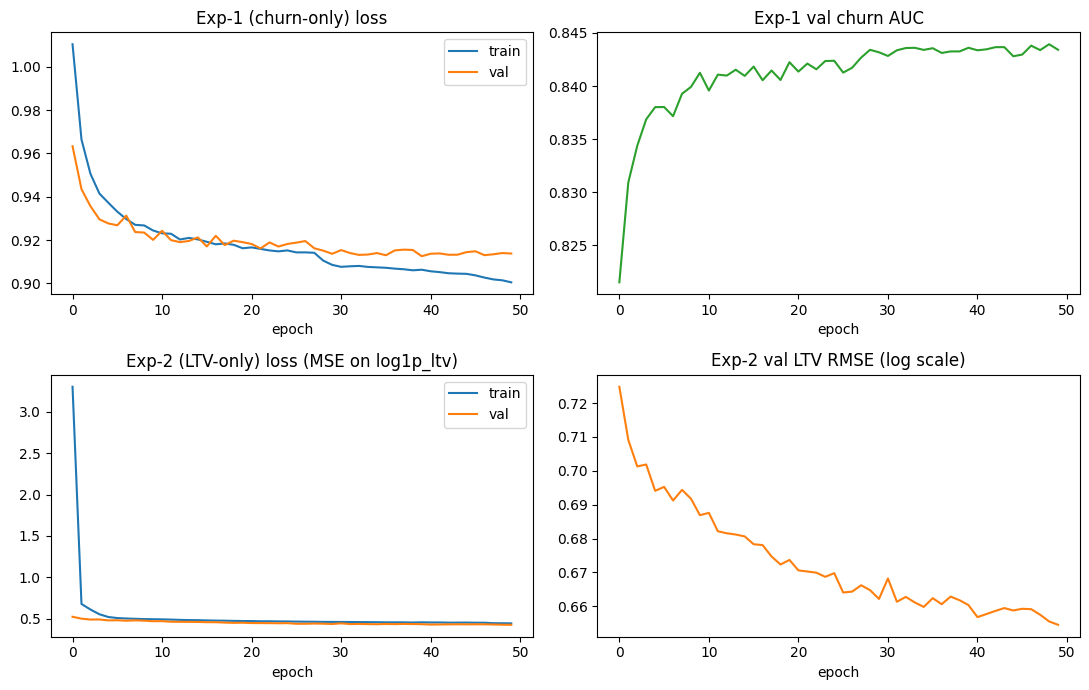

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes[0, 0].plot(hist_exp1["epoch"], hist_exp1["train_loss"], label="train")
axes[0, 0].plot(hist_exp1["epoch"], hist_exp1["val_loss"], label="val")
axes[0, 0].set_title("Exp-1 (churn-only) loss")
axes[0, 0].legend()

axes[0, 1].plot(hist_exp1["epoch"], hist_exp1["val_auc"], color="tab:green")
axes[0, 1].set_title("Exp-1 val churn AUC")

axes[1, 0].plot(hist_exp2["epoch"], hist_exp2["train_loss"], label="train")
axes[1, 0].plot(hist_exp2["epoch"], hist_exp2["val_loss"], label="val")
axes[1, 0].set_title("Exp-2 (LTV-only) loss (MSE on log1p_ltv)")
axes[1, 0].legend()

axes[1, 1].plot(hist_exp2["epoch"], hist_exp2["val_rmse_log"], color="tab:orange")
axes[1, 1].set_title("Exp-2 val LTV RMSE (log scale)")
for ax in axes.flat:
    ax.set_xlabel("epoch")
fig.tight_layout()

## Final evaluation on val/test using the best checkpoints

Per Section 7.1 (churn) and 7.3 (LTV): AUC-ROC, AUC-PR for churn; RMSE/MAE/R² in both log and raw-TWD scale for LTV (`expm1` inverts the `log1p` target transform).

In [8]:
def evaluate_full(model, loader):
    model.eval()
    all_logits, all_churn, all_ltv_pred, all_ltv_true = [], [], [], []
    with torch.no_grad():
        for x_num, x_cat, y_churn, y_ltv in loader:
            churn_logit, ltv_pred = model(x_num, x_cat)
            all_logits.append(churn_logit)
            all_churn.append(y_churn)
            all_ltv_pred.append(ltv_pred)
            all_ltv_true.append(y_ltv)
    logits = torch.cat(all_logits).numpy()
    churn_true = torch.cat(all_churn).numpy()
    probs = torch.sigmoid(torch.from_numpy(logits)).numpy()
    ltv_pred_log = torch.cat(all_ltv_pred).numpy()
    ltv_true_log = torch.cat(all_ltv_true).numpy()
    ltv_pred_raw = np.expm1(ltv_pred_log)
    ltv_true_raw = np.expm1(ltv_true_log)
    return {
        "churn_auc_roc": roc_auc_score(churn_true, probs),
        "churn_auc_pr": average_precision_score(churn_true, probs),
        "ltv_rmse_log": float(np.sqrt(np.mean((ltv_pred_log - ltv_true_log) ** 2))),
        "ltv_rmse_raw_twd": float(np.sqrt(np.mean((ltv_pred_raw - ltv_true_raw) ** 2))),
        "ltv_mae_raw_twd": float(np.mean(np.abs(ltv_pred_raw - ltv_true_raw))),
        "ltv_r2_raw": float(r2_score(ltv_true_raw, ltv_pred_raw)),
    }


model_exp1.load_state_dict(torch.load(os.path.join(MODELS_DIR, "exp1_churn_only.pt"), weights_only=True))
model_exp2.load_state_dict(torch.load(os.path.join(MODELS_DIR, "exp2_ltv_only.pt"), weights_only=True))

results = {
    "exp1_churn_only": {"val": evaluate_full(model_exp1, val_loader), "test": evaluate_full(model_exp1, test_loader)},
    "exp2_ltv_only": {"val": evaluate_full(model_exp2, val_loader), "test": evaluate_full(model_exp2, test_loader)},
}
with open(os.path.join(RESULTS_DIR, "baseline_results.json"), "w") as f:
    json.dump(results, f, indent=2)

results

{'exp1_churn_only': {'val': {'churn_auc_roc': 0.8436045189288062,
   'churn_auc_pr': 0.36877486756182454,
   'ltv_rmse_log': 5.382148742675781,
   'ltv_rmse_raw_twd': 250.67037963867188,
   'ltv_mae_raw_twd': 236.5727996826172,
   'ltv_r2_raw': -8.147791862487793},
  'test': {'churn_auc_roc': 0.8431831987923559,
   'churn_auc_pr': 0.36113670829432026,
   'ltv_rmse_log': 5.380422115325928,
   'ltv_rmse_raw_twd': 250.41201782226562,
   'ltv_mae_raw_twd': 236.32464599609375,
   'ltv_r2_raw': -8.145064353942871}},
 'exp2_ltv_only': {'val': {'churn_auc_roc': 0.5,
   'churn_auc_pr': 0.06392507049818719,
   'ltv_rmse_log': 0.6545115113258362,
   'ltv_rmse_raw_twd': 60.51292419433594,
   'ltv_mae_raw_twd': 33.29834747314453,
   'ltv_r2_raw': 0.4669026732444763},
  'test': {'churn_auc_roc': 0.5,
   'churn_auc_pr': 0.06391835638512153,
   'ltv_rmse_log': 0.672958493232727,
   'ltv_rmse_raw_twd': 60.81231689453125,
   'ltv_mae_raw_twd': 33.470760345458984,
   'ltv_r2_raw': 0.4606638550758362}}}

Exp-1's LTV metrics and Exp-2's churn metrics are meaningless (those heads never received gradient) — they're recorded only because the same `evaluate_full` function runs both, not because they're informative baselines.

## ROC curve (Exp-1) and predicted-vs-actual LTV (Exp-2)

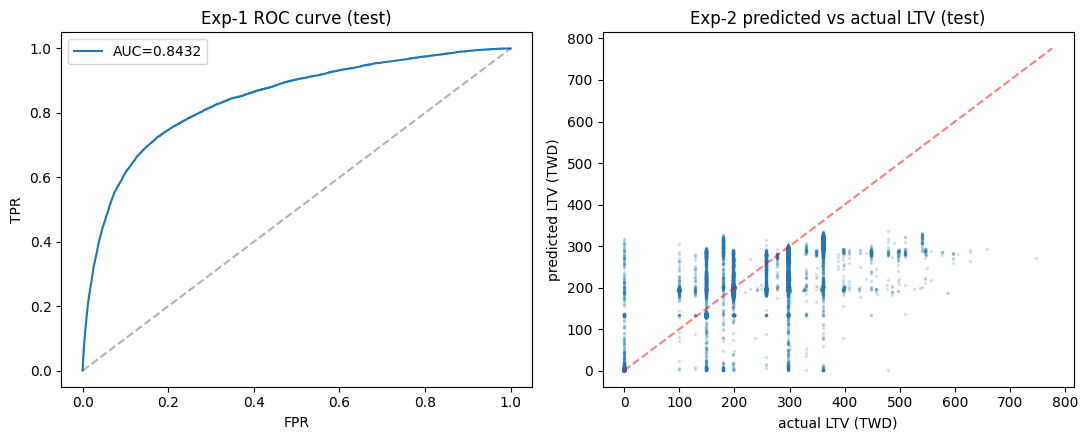

In [9]:
model_exp1.eval()
with torch.no_grad():
    all_logits, all_churn = [], []
    for x_num, x_cat, y_churn, y_ltv in test_loader:
        churn_logit, _ = model_exp1(x_num, x_cat)
        all_logits.append(churn_logit)
        all_churn.append(y_churn)
    probs = torch.sigmoid(torch.cat(all_logits)).numpy()
    churn_true = torch.cat(all_churn).numpy()
fpr, tpr, _ = roc_curve(churn_true, probs)

model_exp2.eval()
with torch.no_grad():
    all_ltv_pred, all_ltv_true = [], []
    for x_num, x_cat, y_churn, y_ltv in test_loader:
        _, ltv_pred = model_exp2(x_num, x_cat)
        all_ltv_pred.append(ltv_pred)
        all_ltv_true.append(y_ltv)
    ltv_pred_raw = np.expm1(torch.cat(all_ltv_pred).numpy())
    ltv_true_raw = np.expm1(torch.cat(all_ltv_true).numpy())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(fpr, tpr, label=f"AUC={results['exp1_churn_only']['test']['churn_auc_roc']:.4f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].set_title("Exp-1 ROC curve (test)")
axes[0].legend()

sample = np.random.choice(len(ltv_pred_raw), size=min(20000, len(ltv_pred_raw)), replace=False)
axes[1].scatter(ltv_true_raw[sample], ltv_pred_raw[sample], s=2, alpha=0.15)
lims = [0, max(ltv_true_raw.max(), ltv_pred_raw.max())]
axes[1].plot(lims, lims, "r--", alpha=0.5)
axes[1].set_xlabel("actual LTV (TWD)")
axes[1].set_ylabel("predicted LTV (TWD)")
axes[1].set_title("Exp-2 predicted vs actual LTV (test)")
fig.tight_layout()